<!-- CURRICULUM_HEADER_START -->
<div class="mh"><p class="mh-crumb"><a href="/series/forecasting/index.html">Forecasting with Machine Learning</a><span class="sep">·</span>Part 3 · Models</p><p class="mh-facts"><span class="lvl lvl-intermediate">Intermediate</span></p><p class="mh-assumes">Assumes <a href="/blogs/forecast/1_feature_engineering.html">Feature engineering with feature_engine</a> and <span class="unwritten" title="not written yet">Gradient boosting for tabular time series</span>.</p></div>
<!-- CURRICULUM_HEADER_END -->

::: {.callout-note appearance="simple" icon=false}
## TL;DR

A single model overfits to the quirks of its training set; averaging three unlike models cuts variance without giving up any one model's strengths. This module fits a `VotingRegressor` of gradient boosting, random forest and ridge on the features from the previous module, trains it on `log(y)`, scores it on a temporal hold-out and rolls it forward eight weeks with climatological weather. You leave able to build and evaluate a leakage-free ensemble forecast.
:::

> **Prerequisite**: see [Feature engineering with feature_engine](../1_feature_engineering/) for how the features are built.

In [1]:
# ── Setup: identical to Tutorial 1 ───────────────────────────────────────────
import pandas as pd
import numpy as np
from datetime import date, timedelta
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from feature_engine.creation import CyclicalFeatures
from feature_engine.encoding import OrdinalEncoder
from feature_engine.timeseries.forecasting import LagFeatures, WindowFeatures
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)
WEATHER_COLS = [
    "temp_mean_c",
    "rainfall_mm",
    "solar_rad_wm2",
    "humidity_pct",
    "wind_speed_ms",
]
FIELDS = ["F01", "F02", "F03", "F04", "F05"]
VARIETIES = {
    "F01": "Chardonnay",
    "F02": "Chardonnay",
    "F03": "Pinot Noir",
    "F04": "Merlot",
    "F05": "Merlot",
}
PREDICTORS = [
    "week_of_year_sin",
    "week_of_year_cos",
    "weeks_since_pruning_sin",
    "weeks_since_pruning_cos",
    "weeks_since_pruning",
    "variety",
    "field_id",
    *WEATHER_COLS,
    "temp_mean_c_lag_1",
    "temp_mean_c_lag_2",
    "temp_mean_c_lag_3",
    "rainfall_mm_lag_1",
    "rainfall_mm_lag_2",
    "rainfall_mm_lag_3",
    "solar_rad_wm2_lag_1",
    "solar_rad_wm2_lag_2",
    "solar_rad_wm2_lag_3",
    "humidity_pct_lag_1",
    "humidity_pct_lag_2",
    "humidity_pct_lag_3",
    "wind_speed_ms_lag_1",
    "temp_mean_c_window_4_mean",
    "rainfall_mm_window_4_mean",
    "solar_rad_wm2_window_4_mean",
    "berry_weight_g_lag_52",
    "berry_weight_g_lag_1",
    "log_weight_lag52",
]
today = date(2026, 3, 14)
last_saturday = today - timedelta(days=(today.weekday() + 2) % 7)
start_date = last_saturday - timedelta(weeks=3 * 52 - 1)
weekly_dates = [start_date + timedelta(weeks=i) for i in range(3 * 52)]


def pruning_week(d):
    woy = (d - date(d.year, 1, 1)).days // 7
    return woy - 8 if woy >= 8 else woy + 52 - 8


def biological_weight_curve(wsp, variety):
    base = {"Chardonnay": 1.8, "Pinot Noir": 1.4, "Merlot": 2.2}[variety]
    w = wsp % 52
    return max(
        0.1,
        base * (1 / (1 + np.exp(-0.3 * (w - 14)))) * (1 - 0.3 * max(0, w - 22) / 30),
    )


records = []
for field in FIELDS:
    variety = VARIETIES[field]
    fe = np.random.normal(0, 0.1)
    for d in weekly_dates:
        wsp = pruning_week(d)
        woy = (d - date(d.year, 1, 1)).days // 7
        base_w = biological_weight_curve(wsp, variety)
        tm = 15 + 10 * np.sin(2 * np.pi * woy / 52) + np.random.normal(0, 2)
        rf = max(0, np.random.exponential(8) * (1 - 0.5 * np.sin(2 * np.pi * woy / 52)))
        sr = 180 + 120 * np.sin(2 * np.pi * (woy - 13) / 52) + np.random.normal(0, 20)
        hm = 60 + 15 * np.cos(2 * np.pi * woy / 52) + np.random.normal(0, 5)
        ws = max(0, np.random.exponential(3))
        we = (
            0.04 * (tm - 15)
            - 0.005 * rf
            + 0.001 * sr
            - 0.002 * hm
            + np.random.normal(0, 0.08)
        )
        records.append(
            {
                "date": d,
                "field_id": field,
                "variety": variety,
                "berry_weight_g": round(max(0.05, base_w + fe + we), 3),
                "week_of_year": woy,
                "weeks_since_pruning": wsp,
                "temp_mean_c": round(tm, 1),
                "rainfall_mm": round(max(0, rf), 1),
                "solar_rad_wm2": round(sr, 1),
                "humidity_pct": round(float(np.clip(hm, 20, 100)), 1),
                "wind_speed_ms": round(ws, 2),
            }
        )
df = pd.DataFrame(records).sort_values(["field_id", "date"]).reset_index(drop=True)

global_fe = Pipeline(
    [
        (
            "cyclical",
            CyclicalFeatures(
                variables=["week_of_year", "weeks_since_pruning"], drop_original=False
            ),
        ),
        (
            "encoding",
            OrdinalEncoder(
                encoding_method="arbitrary", variables=["variety", "field_id"]
            ),
        ),
    ]
)


def _fill_weekly_gaps(X):
    pieces = []
    for field, grp in X.groupby("field_id"):
        grp = grp.set_index("date").sort_index()
        full_idx = pd.date_range(grp.index.min(), grp.index.max(), freq="W-SAT")
        grp = grp.reindex(full_idx)
        grp["date"] = full_idx.date
        grp["field_id"] = field
        grp["_is_gap"] = grp["berry_weight_g"].isna()
        pieces.append(grp.reset_index(drop=True))
    return pd.concat(pieces).sort_values(["field_id", "date"]).reset_index(drop=True)


def _apply_grouped_ts_features(X):
    wl = LagFeatures(variables=WEATHER_COLS, periods=[1, 2, 3], sort_index=False)
    tl = LagFeatures(variables=["berry_weight_g"], periods=[1, 52], sort_index=False)
    ww = WindowFeatures(
        variables=WEATHER_COLS, functions=["mean"], window=4, sort_index=False
    )
    groups = []
    for _, grp in X.groupby("field_id"):
        g = grp.copy()
        g = wl.fit_transform(g)
        g = tl.fit_transform(g)
        g = ww.fit_transform(g)
        groups.append(g)
    result = pd.concat(groups).sort_index()
    return result[~result["_is_gap"]].drop(columns="_is_gap").reset_index(drop=True)


def _add_log_lag52(X):
    X = X.copy()
    X["log_weight_lag52"] = np.log(X["berry_weight_g_lag_52"].clip(lower=0.01))
    return X


grouped_fe = Pipeline(
    [
        ("gap_check", FunctionTransformer(_fill_weekly_gaps)),
        ("ts_features", FunctionTransformer(_apply_grouped_ts_features)),
        ("log_lag52", FunctionTransformer(_add_log_lag52)),
    ]
)

df_global = global_fe.fit_transform(df)
df_transformed = grouped_fe.fit_transform(df_global)
print("Setup complete.", df_transformed.shape)

Setup complete. (780, 38)


## Temporal train/test split

Time series data **cannot be shuffled**: a random split leaks future rows into training. We hold out the last 8 weeks as the test set, so the model has never seen those dates.

Train: 2024-03-23 → 2026-01-17  (480 rows)
Test:  2026-01-24  → 2026-03-14   (40 rows)


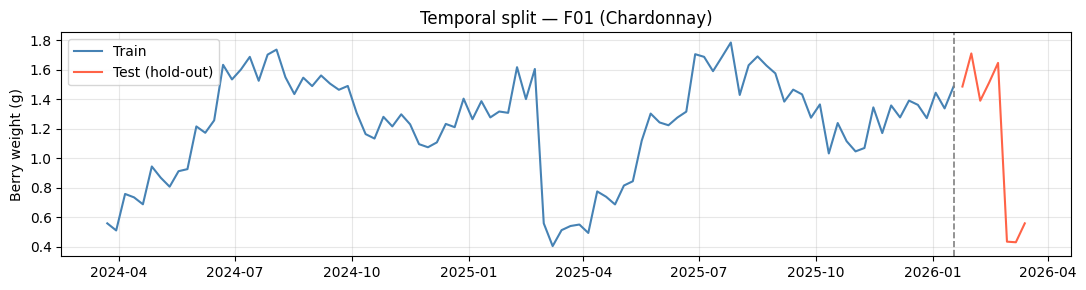

In [2]:
model_df = df_transformed.dropna(subset=PREDICTORS).copy()
cutoff = model_df["date"].max() - timedelta(weeks=8)
train = model_df[model_df["date"] <= cutoff]
test = model_df[model_df["date"] > cutoff]

print(f"Train: {train['date'].min()} → {train['date'].max()}  ({len(train)} rows)")
print(f"Test:  {test['date'].min()}  → {test['date'].max()}   ({len(test)} rows)")

# Visualise split for one field
f01_all = model_df[model_df["field_id"] == 0].sort_values("date")
f01_train = f01_all[f01_all["date"] <= cutoff]
f01_test = f01_all[f01_all["date"] > cutoff]

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(
    f01_train["date"], f01_train["berry_weight_g"], color="steelblue", label="Train"
)
ax.plot(
    f01_test["date"],
    f01_test["berry_weight_g"],
    color="tomato",
    label="Test (hold-out)",
)
ax.axvline(x=cutoff, color="grey", linestyle="--", linewidth=1.2)
ax.set_title("Temporal split — F01 (Chardonnay)")
ax.set_ylabel("Berry weight (g)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## The ensemble model

Three complementary models sit inside a `VotingRegressor`, which averages their predictions:

| Model | Strength |
|-------|----------|
| `GradientBoostingRegressor` | Captures complex non-linear interactions |
| `RandomForestRegressor` | Robust to outliers, low variance |
| `Ridge` | Provides a stable linear baseline |

**`TransformedTargetRegressor`** wraps the ensemble and fits it on `log(y)` rather than `y`. Berry weights are non-negative and right-skewed — a log transform brings residuals closer to Gaussian and prevents negative predictions.

In [3]:
def _select_predictors(X):
    return X[PREDICTORS]


model_pipeline = Pipeline(
    [
        ("select", FunctionTransformer(_select_predictors)),
        (
            "regressor",
            TransformedTargetRegressor(
                regressor=VotingRegressor(
                    estimators=[
                        (
                            "gbr",
                            GradientBoostingRegressor(
                                n_estimators=200,
                                learning_rate=0.05,
                                max_depth=4,
                                random_state=42,
                            ),
                        ),
                        (
                            "rf",
                            RandomForestRegressor(
                                n_estimators=100, max_depth=6, random_state=42
                            ),
                        ),
                        ("ridge", Ridge(alpha=1.0)),
                    ]
                ),
                func=np.log,
                inverse_func=np.exp,
            ),
        ),
    ]
)

model_pipeline.fit(train, train["berry_weight_g"])
print("Model trained.")

Model trained.


### Hold-out evaluation

MAE, RMSE and MAPE on the 40 held-out rows, then actual against predicted per field.

In [4]:
y_pred = model_pipeline.predict(test)
y_actual = test["berry_weight_g"].values

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print("Hold-out evaluation (last 8 weeks, all fields):")
print(f"  MAE  : {mae:.4f} g/berry")
print(f"  RMSE : {rmse:.4f} g/berry")
print(f"  MAPE : {mape:.2f}%")

Hold-out evaluation (last 8 weeks, all fields):
  MAE  : 0.0982 g/berry
  RMSE : 0.1357 g/berry
  MAPE : 16.37%


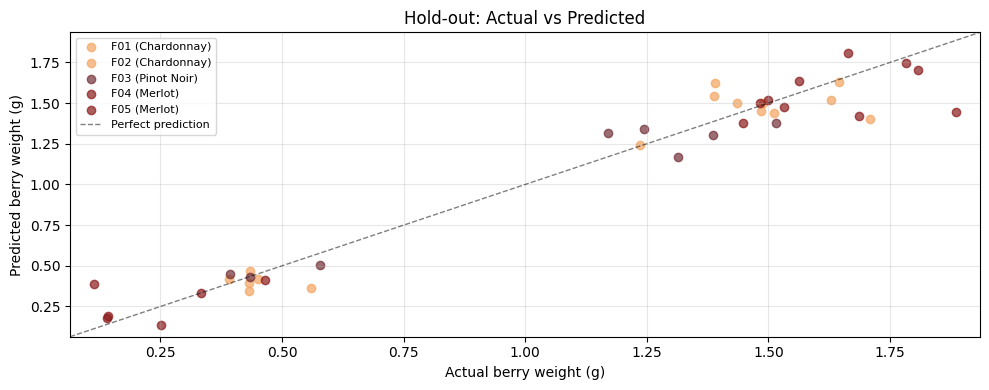

In [5]:
# Actual vs predicted on hold-out set
results = test.copy()
results["predicted"] = y_pred

colors = {"Chardonnay": "#f4a460", "Pinot Noir": "#722f37", "Merlot": "#8b1a1a"}
fig, ax = plt.subplots(figsize=(10, 4))

for field in FIELDS:
    sub = results[
        results["field_id"]
        == global_fe.named_steps["encoding"].encoder_dict_["field_id"][field]
    ]
    variety = VARIETIES[field]
    ax.scatter(
        sub["berry_weight_g"],
        sub["predicted"],
        color=colors[variety],
        alpha=0.7,
        label=f"{field} ({variety})",
    )

lims = [
    min(y_actual.min(), y_pred.min()) - 0.05,
    max(y_actual.max(), y_pred.max()) + 0.05,
]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual berry weight (g)")
ax.set_ylabel("Predicted berry weight (g)")
ax.set_title("Hold-out: Actual vs Predicted")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Eight-week autoregressive forecast

Future weeks have no measured weather, so we substitute same-week **climatology** (3-year field mean). The forecast is **autoregressive**: each step's prediction is written back as `berry_weight_g` so the next step has a valid `lag_1` value.

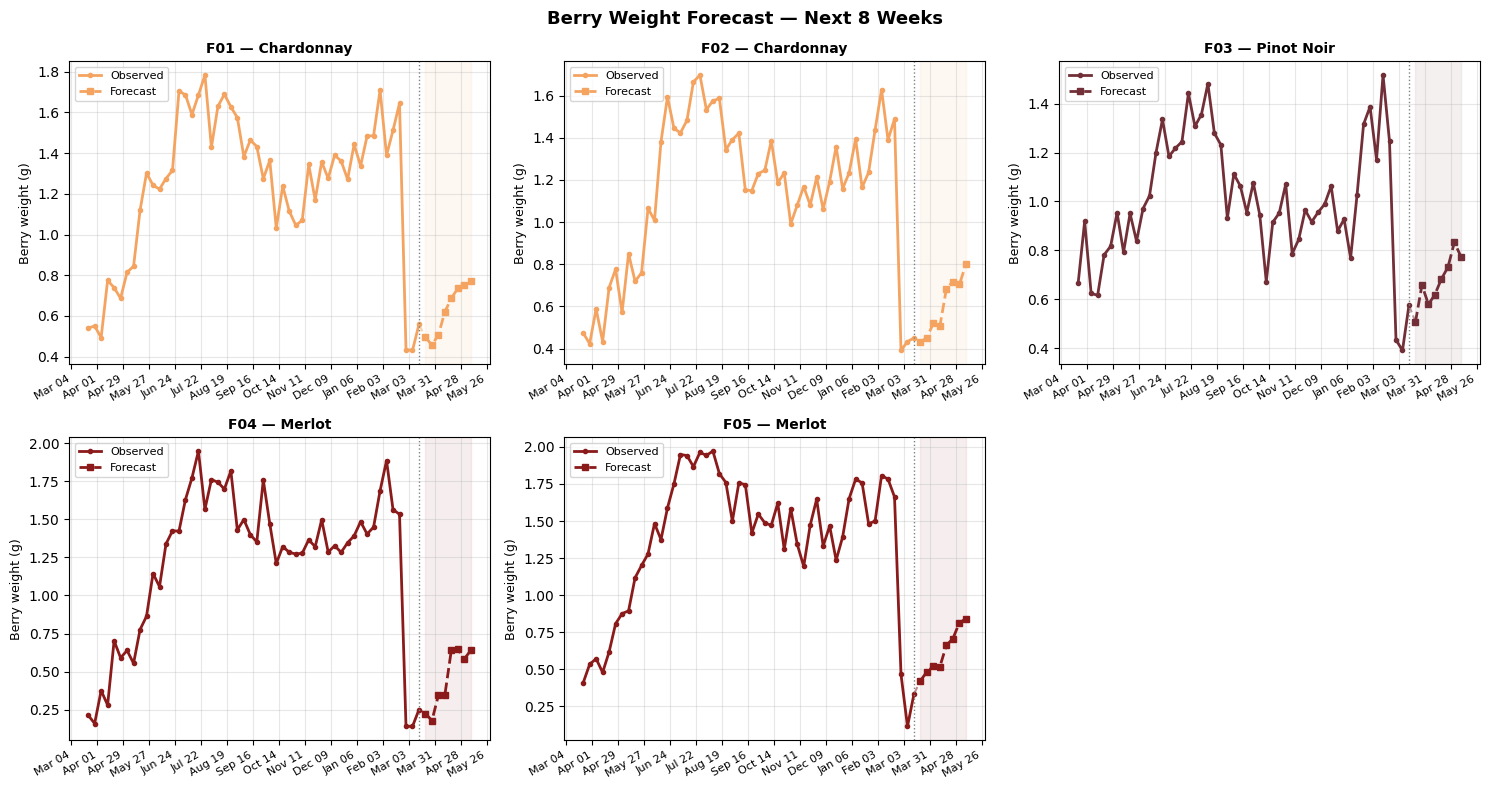

In [6]:
RAW_COLS = df.columns.tolist()
climatology = (
    df.groupby(["field_id", "week_of_year"])[WEATHER_COLS]
    .mean()
    .reset_index()
    .rename(columns={c: f"{c}_clim" for c in WEATHER_COLS})
)

forecast_records = []
df_extended = df.copy()

for step in range(1, 9):
    forecast_date = last_saturday + timedelta(weeks=step)
    woy = (forecast_date - date(forecast_date.year, 1, 1)).days // 7
    rows = []
    for field in FIELDS:
        clim = climatology[
            (climatology["field_id"] == field) & (climatology["week_of_year"] == woy)
        ]
        cv = (
            clim.iloc[0][[f"{c}_clim" for c in WEATHER_COLS]].to_dict()
            if len(clim)
            else {
                f"{c}_clim": df[df["field_id"] == field][c].mean() for c in WEATHER_COLS
            }
        )
        rows.append(
            {
                "date": forecast_date,
                "field_id": field,
                "variety": VARIETIES[field],
                "berry_weight_g": 0.0,
                "week_of_year": woy,
                "weeks_since_pruning": pruning_week(forecast_date),
                **{c: cv[f"{c}_clim"] for c in WEATHER_COLS},
            }
        )
    step_df = pd.DataFrame(rows)
    df_combined = pd.concat(
        [df_extended[RAW_COLS], step_df[RAW_COLS]], ignore_index=True
    )
    df_step = grouped_fe.transform(global_fe.transform(df_combined))
    X_fc = df_step[df_step["date"] == forecast_date]
    step_df["berry_weight_g"] = model_pipeline.predict(X_fc)
    step_df["pred_weight_g"] = step_df["berry_weight_g"]
    step_df["forecast_step"] = step
    df_extended = pd.concat([df_extended, step_df], ignore_index=True)
    forecast_records.append(
        step_df[
            [
                "date",
                "field_id",
                "variety",
                "forecast_step",
                "weeks_since_pruning",
                "pred_weight_g",
            ]
        ]
    )

forecast_df = pd.concat(forecast_records, ignore_index=True)

colors_variety = {"Chardonnay": "#f4a460", "Pinot Noir": "#722f37", "Merlot": "#8b1a1a"}
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
axes = axes.flatten()
fig.suptitle("Berry Weight Forecast — Next 8 Weeks", fontsize=13, fontweight="bold")

for idx, field in enumerate(FIELDS):
    ax = axes[idx]
    variety = VARIETIES[field]
    hist = df[df["field_id"] == field].sort_values("date").tail(52)
    fc = forecast_df[forecast_df["field_id"] == field].sort_values("date")
    ax.plot(
        hist["date"],
        hist["berry_weight_g"],
        color=colors_variety[variety],
        linewidth=2,
        marker="o",
        markersize=3,
        label="Observed",
    )
    ax.plot(
        [hist["date"].iloc[-1], fc["date"].iloc[0]],
        [hist["berry_weight_g"].iloc[-1], fc["pred_weight_g"].iloc[0]],
        color=colors_variety[variety],
        linewidth=1.5,
        linestyle="--",
        alpha=0.5,
    )
    ax.plot(
        fc["date"],
        fc["pred_weight_g"],
        color=colors_variety[variety],
        linewidth=2,
        linestyle="--",
        marker="s",
        markersize=5,
        label="Forecast",
    )
    ax.axvspan(
        fc["date"].min(), fc["date"].max(), alpha=0.07, color=colors_variety[variety]
    )
    ax.axvline(x=last_saturday, color="grey", linestyle=":", linewidth=1)
    ax.set_title(f"{field} — {variety}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Berry weight (g)", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=4))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## Key takeaways

- **No data leakage**: the temporal split ensures the model never sees future dates during training.
- **`VotingRegressor`** averages three complementary learners, reducing prediction variance.
- **`TransformedTargetRegressor`** with `func=np.log` stabilises the target distribution without manual pre/post-processing.
- On the 8-week hold-out the ensemble reaches MAE 0.098 g per berry and MAPE 16.4%.
- **Autoregressive forecasting** with climatology weather is a practical baseline when future conditions are unknown — each step's prediction feeds the next step's `lag_1`.

The next module examines *why* the model makes specific predictions using SHAP values.

<!-- CURRICULUM_FOOTER_START -->
<div class="mf"><a class="mf-prev" href="/blogs/forecast/1_feature_engineering.html"><span>Previous</span>Feature engineering with feature_engine</a><a class="mf-up" href="/series/forecasting/index.html"><span>Series</span>Forecasting with Machine Learning</a><a class="mf-next" href="/blogs/forecast/3_shap_explainability.html"><span>Next</span>SHAP</a></div>
<!-- CURRICULUM_FOOTER_END -->